In [24]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


In [1]:
# ================================================================
# PPC: Location-level time-averaged proportion
# One-step-ahead posterior ranking p-values
# 5 MODELS:
#   IID / BYM shared / BYM weekly / BYM+cov / BYM weekly+cov
# ================================================================

import numpy as np
import pyreadr
import pickle
import pandas as pd
from pathlib import Path
from tqdm import tqdm

np.random.seed(1)

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
N_REP = 1000

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# LOAD DATA
# ================================================================

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

# ================================================================
# LOAD DATA — EXACT SAME 2PC FILTER AS MODEL FITTING
# ================================================================

import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# 1) remove isolated
coords_tmp = np.delete(coords_full, no_nbs, axis=0)
y_tmp = np.delete(y_full, no_nbs, axis=0)

# 2) build adjacency
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_tmp[:,0], coords_tmp[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

# 3) keep two largest connected components
n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_tmp[keep]
y = y_tmp[keep]

S, T = y.shape

print("Using S =", S)

# ================================================================
# OBSERVED STATISTIC
# ================================================================

T_obs = y[:,1:].mean(axis=1)  # (S,)

# ================================================================
# TIME COVARIATES
# ================================================================

t_raw = np.arange(1, T+1)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov4 = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD),
    t_trend
])

cov8 = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD), np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD), np.sin(2*np.pi*t_raw/PERIOD),
    t_trend, t_trend
])

week = (t_raw - 1) % 52

# ================================================================
# SPATIAL COVARIATES (SAFE VERSION)
# ================================================================

# ---- latitude
lat = coords[:,1]
lat = (lat - lat.mean()) / lat.std()

# ---- elevation (safe read)
elev_df = pd.read_csv(BASE_DIR / "curr_elev.csv")
elev_all = elev_df.iloc[:,3].to_numpy()

# 2️⃣ keep 2pc
elev = elev_all[keep]

# scale
elev = (elev - elev.mean()) / elev.std()

# ---- temperature
snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)

temp_all = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()

# 2pc subset
temp = temp_all[keep]

# scale
temp = (temp - temp.mean()) / temp.std()

# ================================================================
# LOAD POSTERIORS
# ================================================================

iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

bym01 = np.load(BASE_DIR / "bym01.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10.npz")["all_theta"]

bym01_cov = np.load(BASE_DIR / "bym01_cov.npz")["all_theta"]
bym10_cov = np.load(BASE_DIR / "bym10_cov.npz")["all_theta"]

with open(BASE_DIR / "bym01_weekly.pkl","rb") as f:
    weekly01 = pickle.load(f)
with open(BASE_DIR / "bym10_weekly.pkl","rb") as f:
    weekly10 = pickle.load(f)

eta01_week = weekly01["all_eta"]
tau01_week = weekly01["all_tau"]
eta10_week = weekly10["all_eta"]
tau10_week = weekly10["all_tau"]

with open(BASE_DIR / "bym01_cov_weekly_tau9.pkl","rb") as f:
    wf01 = pickle.load(f)
with open(BASE_DIR / "bym10_cov_weekly_tau9.pkl","rb") as f:
    wf10 = pickle.load(f)

eta01_wf = wf01["all_eta"]
tau01_wf = wf01["all_tau"]
eta10_wf = wf10["all_eta"]
tau10_wf = wf10["all_tau"]

M = iid01.shape[1]

# ================================================================
# SIGMOID
# ================================================================

def sigmoid(z):
    z = np.clip(z,-30,30)
    return 1/(1+np.exp(-z))

# ================================================================
# GENERIC ONE-STEP-AHEAD SIMULATOR
# ================================================================

def simulate(get_eta):

    draws = np.random.choice(M, N_REP, replace=False)
    T_pred = np.zeros((N_REP, S))

    for j, m in enumerate(tqdm(draws)):

        y_rep = np.zeros((S,T), dtype=int)
        y_rep[:,0] = y[:,0]

        for t in range(1,T):

            eta01, eta10 = get_eta(m,t-1)

            p01 = sigmoid(eta01)
            p10 = sigmoid(eta10)

            prev = y_rep[:,t-1]

            prob = np.where(prev==0, p01, 1-p10)

            y_rep[:,t] = np.random.binomial(1, prob)

        T_pred[j,:] = y_rep[:,1:].mean(axis=1)

    return np.mean(T_pred >= T_obs, axis=0)

# ================================================================
# ETA DEFINITIONS
# ================================================================

def eta_iid(m,t):
    e1 = sum(cov4[t,k] * iid01[k*S:(k+1)*S,m] for k in range(4))
    e2 = sum(cov4[t,k] * iid10[k*S:(k+1)*S,m] for k in range(4))
    return e1, e2


def eta_week(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_week[k*S:(k+1)*S,m]
        beta2 = eta10_week[k*S:(k+1)*S,m]
        e1 += cov8[t,k] * beta1 * tau01_week[k*52+w,m]
        e2 += cov8[t,k] * beta2 * tau10_week[k*52+w,m]
    return e1, e2

def eta_week_cov(m, t):

    w = week[t]

    e1 = np.zeros(S)
    e2 = np.zeros(S)

    # ----------------------------
    # 1️⃣ spatial BYM weekly part
    # ----------------------------
    for k in range(8):

        # spatial beta blocks
        beta1 = eta01_wf[k*S:(k+1)*S, m]
        beta2 = eta10_wf[k*S:(k+1)*S, m]

        # weekly scaling
        scale1 = tau01_wf[k*52 + w, m]
        scale2 = tau10_wf[k*52 + w, m]

        e1 += cov8[t, k] * beta1 * scale1
        e2 += cov8[t, k] * beta2 * scale2

    # ----------------------------
    # 2️⃣ global covariate part
    # ----------------------------
    gamma1 = eta01_wf[8*S : 8*S+3, m]
    gamma2 = eta10_wf[8*S : 8*S+3, m]

    fac = np.column_stack([
        t_trend[t] * lat,
        t_trend[t] * elev,
        t_trend[t] * temp[:, t]
    ])

    e1 += fac @ gamma1
    e2 += fac @ gamma2

    return e1, e2

# ================================================================
# RUN ALL MODELS
# ================================================================

print("\nIID")
p_iid = simulate(eta_iid)

print("\nBYM weekly")
p_week = simulate(eta_week)

print("\nBYM weekly + cov")
p_week_cov = simulate(eta_week_cov)

# ================================================================
# SUMMARY
# ================================================================

def summarize(name, pvals):
    print("\n", name)
    print("Mean:", pvals.mean())
    print("SD:", pvals.std())
    print("Pr(p<0.05):", np.mean(pvals < 0.05))
    print("Pr(p>0.95):", np.mean(pvals > 0.95))

summarize("IID", p_iid)
summarize("BYM weekly", p_week)
summarize("BYM weekly+cov", p_week_cov)

Using S = 1557

IID


100%|██████████| 1000/1000 [08:39<00:00,  1.93it/s]



BYM weekly


100%|██████████| 1000/1000 [12:30<00:00,  1.33it/s]



BYM weekly + cov


100%|██████████| 1000/1000 [14:40<00:00,  1.14it/s]


 IID
Mean: 0.49278034682080923
SD: 0.06692848817668295
Pr(p<0.05): 0.0
Pr(p>0.95): 0.0

 BYM weekly
Mean: 0.5074348105330765
SD: 0.07527512642626456
Pr(p<0.05): 0.0
Pr(p>0.95): 0.0

 BYM weekly+cov
Mean: 0.4951547848426461
SD: 0.08622454925701133
Pr(p<0.05): 0.0
Pr(p>0.95): 0.0


In [28]:
# ================================================================
# SAVE PPC MAP DATA FOR R
# ================================================================

import pandas as pd

df_map = pd.DataFrame({
    "x": coords[:,0],
    "y": coords[:,1],
    "p_iid": p_iid,
    "p_week": p_week,
    "p_week_cov": p_week_cov
})

df_map.to_csv(BASE_DIR / "ppc_time_avg_pvalues.csv", index=False)

print("Saved to ppc_time_avg_pvalues.csv")

Saved to ppc_time_avg_pvalues.csv


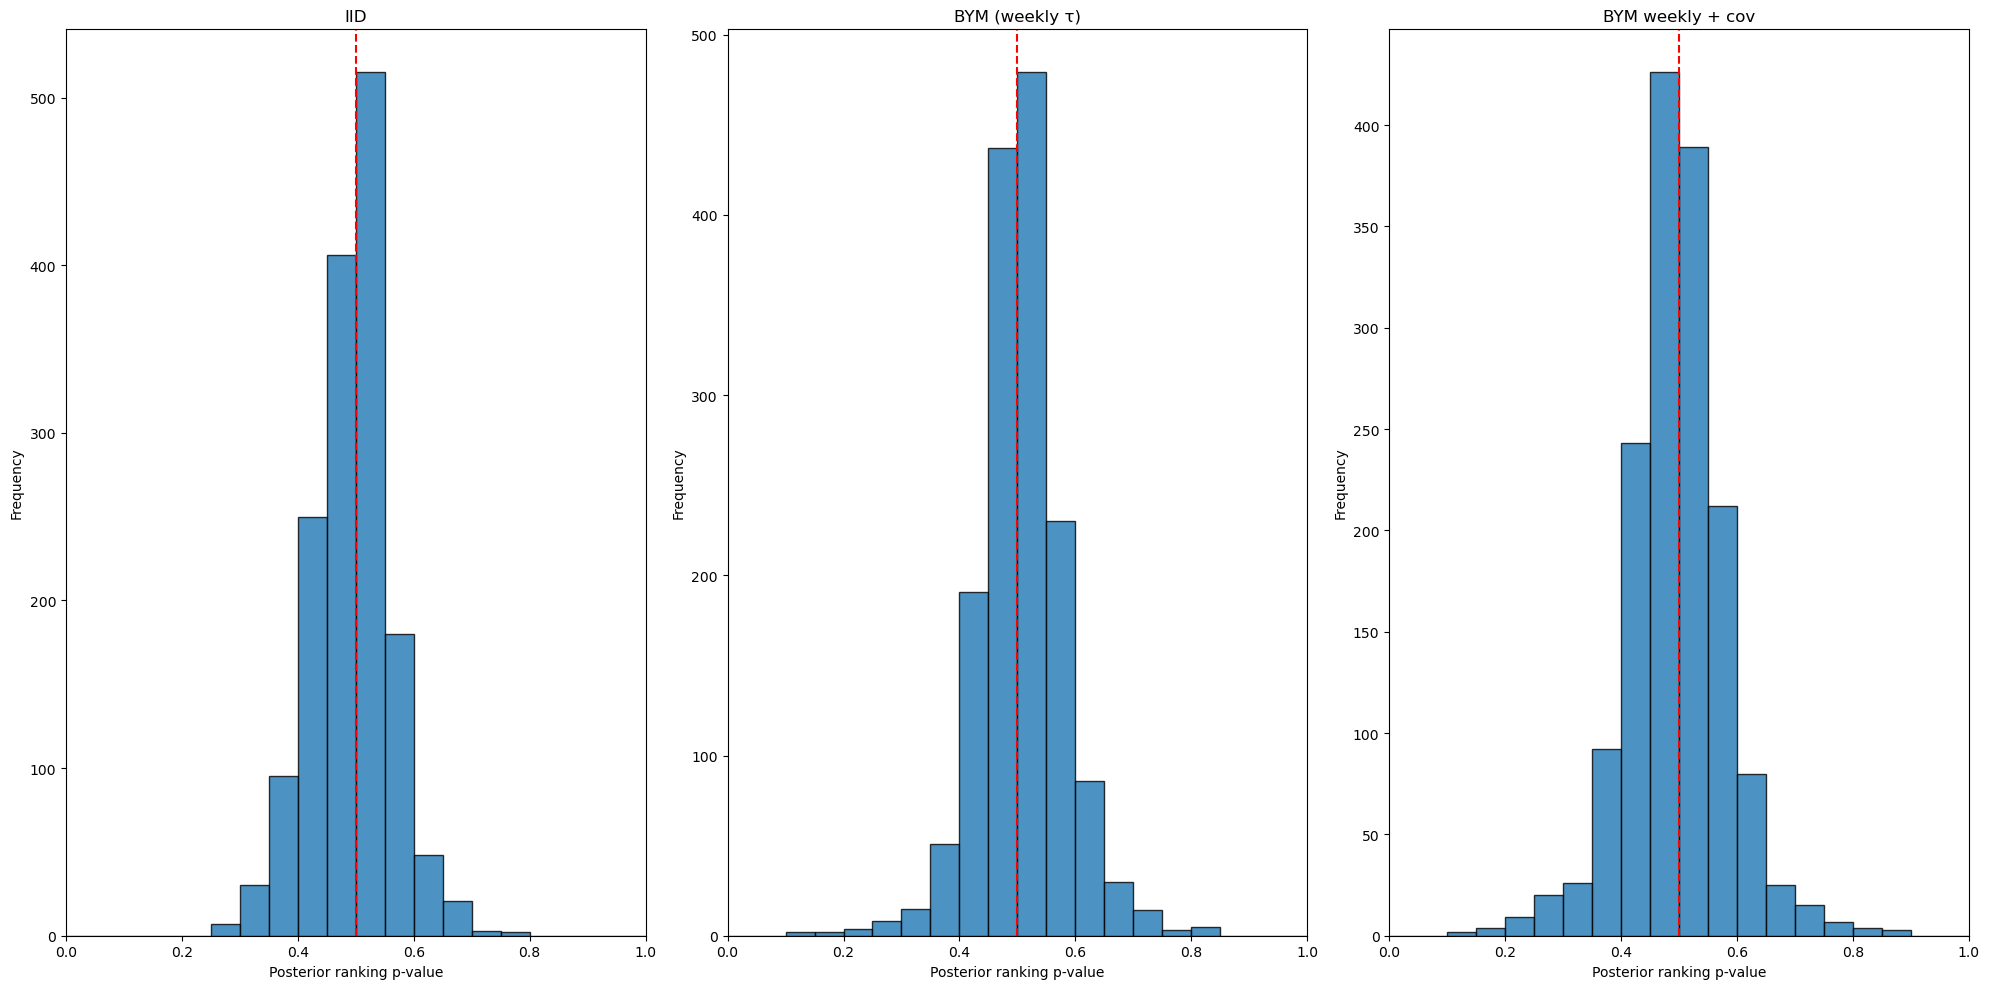

In [2]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 1, 21)

fig, axes = plt.subplots(1, 3, figsize=(20,10))

# ---------------------------
# IID
# ---------------------------
axes[0].hist(p_iid, bins=bins, edgecolor="black", alpha=0.8)
axes[0].axvline(0.5, color="red", linestyle="--")
axes[0].set_title("IID")
axes[0].set_xlim(0,1)


# ---------------------------
# BYM weekly
# ---------------------------
axes[1].hist(p_week, bins=bins, edgecolor="black", alpha=0.8)
axes[1].axvline(0.5, color="red", linestyle="--")
axes[1].set_title("BYM (weekly τ)")
axes[1].set_xlim(0,1)


# ---------------------------
# BYM weekly + cov
# ---------------------------
axes[2].hist(p_week_cov, bins=bins, edgecolor="black", alpha=0.8)
axes[2].axvline(0.5, color="red", linestyle="--")
axes[2].set_title("BYM weekly + cov")
axes[2].set_xlim(0,1)

for ax in axes.flat:
    ax.set_xlabel("Posterior ranking p-value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [3]:
# ================================================================
# IMPORTS
# ================================================================
import numpy as np
import pyreadr
import pickle
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

np.random.seed(1)

# ================================================================
# CONFIG
# ================================================================
BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
N_REP = 1000

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1


# ================================================================
# LOAD DATA
# ================================================================
snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

# remove isolated
coords_tmp = np.delete(coords_full, no_nbs, axis=0)
y_tmp = np.delete(y_full, no_nbs, axis=0)

# build adjacency
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_tmp[:,0], coords_tmp[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

# keep two largest components
n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_tmp[keep]
y = y_tmp[keep]

S, T = y.shape
print("Using S =", S)


# ================================================================
# OBSERVED WEEKLY STATISTIC
# ================================================================
t_raw = np.arange(1, T+1)
week = (t_raw - 1) % 52
week_indices = [(week == w) for w in range(52)]

# ================================================================
# OBSERVED: overall weekly snow proportion
# ================================================================

T_obs_week = np.zeros(52)

for w in range(52):
    idx = week_indices[w]
    T_obs_week[w] = y[:, idx].mean()

print("Observed weekly shape:", T_obs_week.shape)


# ================================================================
# TIME COVARIATES
# ================================================================
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov4 = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD),
    t_trend
])

cov8 = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD), np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD), np.sin(2*np.pi*t_raw/PERIOD),
    t_trend, t_trend
])


# ================================================================
# SPATIAL COVARIATES
# ================================================================
lat = coords[:,1]
lat = (lat - lat.mean()) / lat.std()

elev_df = pd.read_csv(BASE_DIR / "curr_elev.csv")
elev_all = elev_df.iloc[:,3].to_numpy()
elev = elev_all[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_all = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp = temp_all[keep]
temp = (temp - temp.mean()) / temp.std()


# ================================================================
# LOAD POSTERIORS
# ================================================================
iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

with open(BASE_DIR / "bym01_weekly.pkl","rb") as f:
    weekly01 = pickle.load(f)
with open(BASE_DIR / "bym10_weekly.pkl","rb") as f:
    weekly10 = pickle.load(f)

eta01_week = weekly01["all_eta"]
tau01_week = weekly01["all_tau"]
eta10_week = weekly10["all_eta"]
tau10_week = weekly10["all_tau"]

with open(BASE_DIR / "bym01_cov_weekly_tau9.pkl","rb") as f:
    wf01 = pickle.load(f)
with open(BASE_DIR / "bym10_cov_weekly_tau9.pkl","rb") as f:
    wf10 = pickle.load(f)

eta01_wf = wf01["all_eta"]
tau01_wf = wf01["all_tau"]
eta10_wf = wf10["all_eta"]
tau10_wf = wf10["all_tau"]

M = iid01.shape[1]


# ================================================================
# SIGMOID
# ================================================================
def sigmoid(z):
    z = np.clip(z,-30,30)
    return 1/(1+np.exp(-z))


# ================================================================
# ETA DEFINITIONS
# ================================================================
def eta_iid(m,t):
    e1 = sum(cov4[t,k]*iid01[k*S:(k+1)*S,m] for k in range(4))
    e2 = sum(cov4[t,k]*iid10[k*S:(k+1)*S,m] for k in range(4))
    return e1,e2

def eta_week(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_week[k*S:(k+1)*S,m]
        beta2 = eta10_week[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_week[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_week[k*52+w,m]
    return e1,e2

def eta_week_cov(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_wf[k*S:(k+1)*S,m]
        beta2 = eta10_wf[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_wf[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_wf[k*52+w,m]

    gamma1 = eta01_wf[8*S:8*S+3,m]
    gamma2 = eta10_wf[8*S:8*S+3,m]

    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])

    return e1+fac@gamma1, e2+fac@gamma2


# ================================================================
# SIMULATOR (overall weekly proportion)
# ================================================================

def simulate_weekly_summary(get_eta):

    draws = np.random.choice(M, N_REP, replace=False)
    T_pred = np.zeros((N_REP, 52))

    for j, m in enumerate(tqdm(draws)):

        y_rep = np.zeros((S,T), dtype=int)
        y_rep[:,0] = y[:,0]

        for t in range(1,T):

            eta01, eta10 = get_eta(m, t-1)

            p01 = sigmoid(eta01)
            p10 = sigmoid(eta10)

            prev = y_rep[:,t-1]
            prob = np.where(prev==0, p01, 1-p10)

            y_rep[:,t] = np.random.binomial(1, prob)

        for w in range(52):
            idx = week_indices[w]
            T_pred[j,w] = y_rep[:, idx].mean()

    mean = T_pred.mean(axis=0)
    low  = np.percentile(T_pred, 2.5, axis=0)
    up   = np.percentile(T_pred, 97.5, axis=0)

    return mean, low, up


# ================================================================
# RUN MODELS
# ================================================================
print("\nIID")
mean_iid, low_iid, up_iid = simulate_weekly_summary(eta_iid)

print("\nBYM weekly")
mean_week, low_week, up_week = simulate_weekly_summary(eta_week)

print("\nBYM weekly + cov")
mean_week_cov, low_week_cov, up_week_cov = simulate_weekly_summary(eta_week_cov)


weeks = np.arange(52)


Using S = 1557
Observed weekly shape: (52,)

IID


100%|██████████| 1000/1000 [09:00<00:00,  1.85it/s]



BYM weekly


100%|██████████| 1000/1000 [12:24<00:00,  1.34it/s]



BYM weekly + cov


100%|██████████| 1000/1000 [14:17<00:00,  1.17it/s]


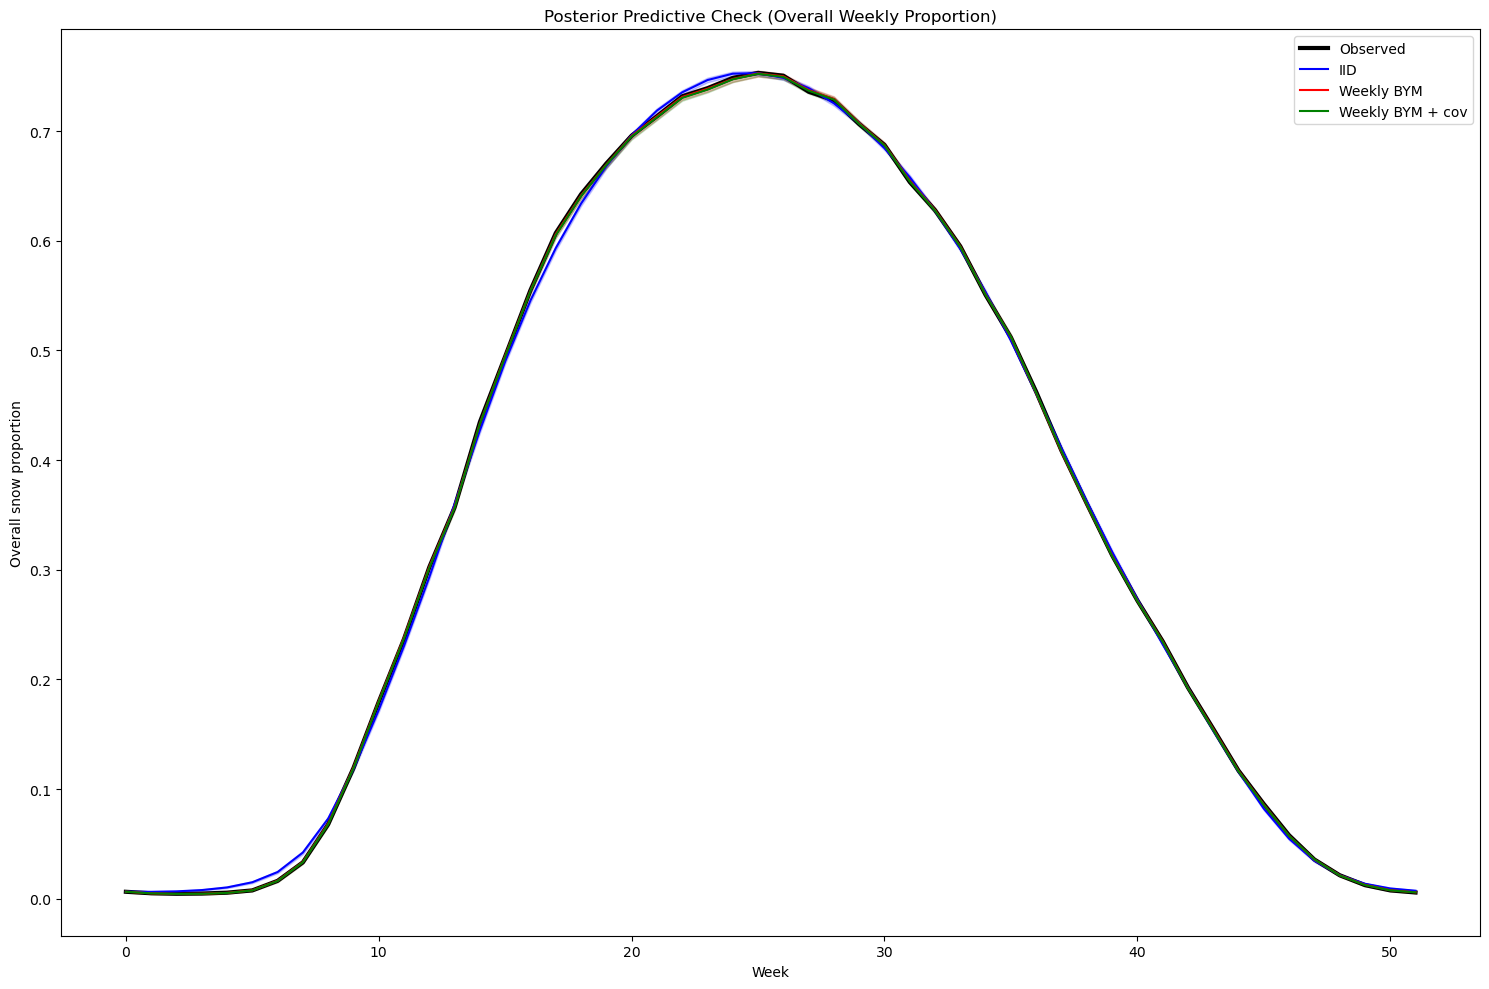

In [12]:

plt.figure(figsize=(15,10))

# observed
plt.plot(weeks, T_obs_week,
         color="black", linewidth=3, label="Observed")

# IID
plt.plot(weeks, mean_iid, color="blue", label="IID")
plt.fill_between(weeks, low_iid, up_iid,
                 color="blue", alpha=0.2)

# Weekly BYM
plt.plot(weeks, mean_week, color="red", label="Weekly BYM")
plt.fill_between(weeks, low_week, up_week,
                 color="red", alpha=0.2)

# Weekly BYM + cov
plt.plot(weeks, mean_week_cov, color="green", label="Weekly BYM + cov")
plt.fill_between(weeks, low_week_cov, up_week_cov,
                 color="green", alpha=0.2)

plt.xlabel("Week")
plt.ylabel("Overall snow proportion")
plt.title("Posterior Predictive Check (Overall Weekly Proportion)")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# ================================================================
# COVERAGE FUNCTION
# ================================================================
# ================================================================
# COVERAGE (global weekly proportion)
# ================================================================
def compute_coverage(obs, low, up):

    cover = (obs >= low) & (obs <= up)   # shape (52,)

    overall = cover.mean()              # proportion of 52 weeks covered

    return overall, cover

print("\nComputing coverage rates...")

cov_iid, cover_iid = compute_coverage(T_obs_week, low_iid, up_iid)
cov_week, cover_week = compute_coverage(T_obs_week, low_week, up_week)
cov_wcov, cover_wcov = compute_coverage(T_obs_week, low_week_cov, up_week_cov)

print("\n===================================")
print("Coverage over 52 weeks")
print("===================================")

print(f"IID:                 {cov_iid:.3f}")
print(f"Weekly BYM:          {cov_week:.3f}")
print(f"Weekly BYM + cov:    {cov_wcov:.3f}")


Computing coverage rates...

Coverage over 52 weeks
IID:                 0.269
Weekly BYM:          1.000
Weekly BYM + cov:    1.000


Using S = 1557
Observed weekly shape: (52,)


BYM weekly + cov: 100%|██████████| 1000/1000 [14:11<00:00,  1.18it/s]


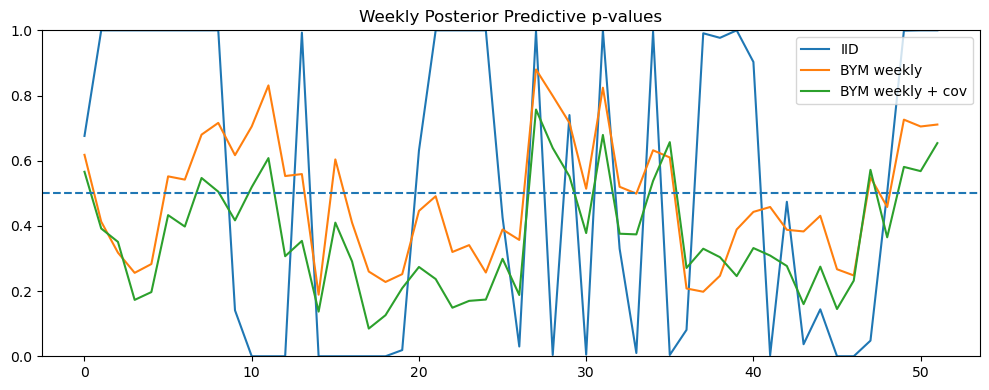


Global PPP
IID      : 0.225
BYM week : 0.379
BYM+cov  : 0.034


In [ ]:
# ================================================================
# IMPORTS
# ================================================================
import numpy as np
import pyreadr
import pickle
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

np.random.seed(1)

# ================================================================
# CONFIG
# ================================================================
BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
N_REP = 1000

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1


# ================================================================
# LOAD DATA
# ================================================================
snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

coords_tmp = np.delete(coords_full, no_nbs, axis=0)
y_tmp = np.delete(y_full, no_nbs, axis=0)

# ================================================================
# BUILD ADJACENCY
# ================================================================
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_tmp[:,0], coords_tmp[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

# keep two largest components
n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_tmp[keep]
y = y_tmp[keep]

S, T = y.shape
print("Using S =", S)


# ================================================================
# WEEK INDEX
# ================================================================
t_raw = np.arange(1, T+1)
week = (t_raw - 1) % 52
week_indices = [(week == w) for w in range(52)]


# ================================================================
# OBSERVED WEEKLY STATISTIC
# ================================================================
T_obs_week = np.zeros(52)

for w in range(52):
    idx = week_indices[w]
    T_obs_week[w] = y[:, idx].mean()

print("Observed weekly shape:", T_obs_week.shape)


# ================================================================
# TIME COVARIATES
# ================================================================
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov4 = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD),
    t_trend
])

cov8 = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD), np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD), np.sin(2*np.pi*t_raw/PERIOD),
    t_trend, t_trend
])


# ================================================================
# SPATIAL COVARIATES
# ================================================================
lat = coords[:,1]
lat = (lat - lat.mean()) / lat.std()

elev_df = pd.read_csv(BASE_DIR / "curr_elev.csv")
elev_all = elev_df.iloc[:,3].to_numpy()
elev = elev_all[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_all = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp = temp_all[keep]
temp = (temp - temp.mean()) / temp.std()


# ================================================================
# LOAD POSTERIORS
# ================================================================
iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

with open(BASE_DIR / "bym01_weekly.pkl","rb") as f:
    weekly01 = pickle.load(f)
with open(BASE_DIR / "bym10_weekly.pkl","rb") as f:
    weekly10 = pickle.load(f)

eta01_week = weekly01["all_eta"]
tau01_week = weekly01["all_tau"]
eta10_week = weekly10["all_eta"]
tau10_week = weekly10["all_tau"]

with open(BASE_DIR / "bym01_cov_weekly_tau9.pkl","rb") as f:
    wf01 = pickle.load(f)
with open(BASE_DIR / "bym10_cov_weekly_tau9.pkl","rb") as f:
    wf10 = pickle.load(f)

eta01_wf = wf01["all_eta"]
tau01_wf = wf01["all_tau"]
eta10_wf = wf10["all_eta"]
tau10_wf = wf10["all_tau"]

M = iid01.shape[1]


# ================================================================
# SIGMOID
# ================================================================
def sigmoid(z):
    z = np.clip(z,-30,30)
    return 1/(1+np.exp(-z))


# ================================================================
# ETA FUNCTIONS
# ================================================================
def eta_iid(m,t):
    e1 = sum(cov4[t,k]*iid01[k*S:(k+1)*S,m] for k in range(4))
    e2 = sum(cov4[t,k]*iid10[k*S:(k+1)*S,m] for k in range(4))
    return e1,e2


def eta_week(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        e1 += cov8[t,k] * eta01_week[k*S:(k+1)*S,m] * tau01_week[k*52+w,m]
        e2 += cov8[t,k] * eta10_week[k*S:(k+1)*S,m] * tau10_week[k*52+w,m]
    return e1,e2


def eta_week_cov(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)

    for k in range(8):
        e1 += cov8[t,k] * eta01_wf[k*S:(k+1)*S,m] * tau01_wf[k*52+w,m]
        e2 += cov8[t,k] * eta10_wf[k*S:(k+1)*S,m] * tau10_wf[k*52+w,m]

    gamma1 = eta01_wf[8*S:8*S+3,m]
    gamma2 = eta10_wf[8*S:8*S+3,m]

    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])

    return e1 + fac @ gamma1, e2 + fac @ gamma2


# ================================================================
# SIMULATION + PPP
# ================================================================
def run_ppp(get_eta, name):

    draws = np.random.choice(M, N_REP, replace=False)
    T_pred = np.zeros((N_REP, 52))

    for j, m in enumerate(tqdm(draws, desc=name)):

        y_rep = np.zeros((S,T), dtype=int)
        y_rep[:,0] = y[:,0]

        for t in range(1,T):

            eta01, eta10 = get_eta(m, t-1)

            p01 = sigmoid(eta01)
            p10 = sigmoid(eta10)

            prev = y_rep[:,t-1]
            prob = np.where(prev==0, p01, 1-p10)

            y_rep[:,t] = np.random.binomial(1, prob)

        for w in range(52):
            idx = week_indices[w]
            T_pred[j,w] = y_rep[:, idx].mean()

    ppp = (T_pred >= T_obs_week).mean(axis=0)

    return T_pred, ppp


# ================================================================
# RUN
# ================================================================
pred_iid, ppp_iid = run_ppp(eta_iid, "IID")
pred_week, ppp_week = run_ppp(eta_week, "BYM weekly")
pred_week_cov, ppp_week_cov = run_ppp(eta_week_cov, "BYM weekly + cov")



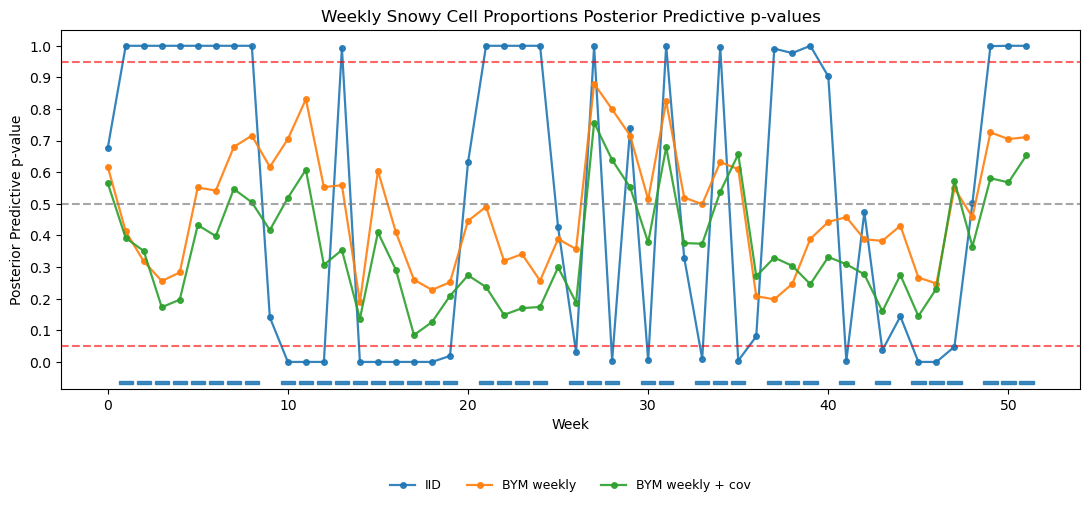

In [20]:
weeks = np.arange(52)

plt.figure(figsize=(11,5))

colors = {
    "IID": "tab:blue",
    "BYM weekly": "tab:orange",
    "BYM weekly + cov": "tab:green"
}

series = {
    "IID": ppp_iid,
    "BYM weekly": ppp_week,
    "BYM weekly + cov": ppp_week_cov
}

# ---- Main curves ----
for name, values in series.items():
    plt.plot(
        weeks,
        values,
        color=colors[name],
        linewidth=1.6,
        marker="o",
        markersize=4,
        alpha=0.9,
        label=name
    )

# ---- Abnormal bands ----
band_height = 0.010
band_positions = {
    "IID": -0.070,
    "BYM weekly": -0.055,
    "BYM weekly + cov": -0.040
}

for name, values in series.items():
    mask = (values < 0.05) | (values > 0.95)
    y0 = band_positions[name]

    for w in weeks[mask]:
        plt.gca().add_patch(
            plt.Rectangle(
                (w - 0.4, y0),
                0.8,
                band_height,
                color=colors[name],
                alpha=0.85
            )
        )

# ---- Left annotation ----
band_min = -0.070
band_max = -0.040 + band_height
band_center = (band_min + band_max) / 2


# ---- Reference lines ----
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7)
plt.axhline(0.05, linestyle="--", color="red", alpha=0.6)
plt.axhline(0.95, linestyle="--", color="red", alpha=0.6)

plt.ylim(-0.085, 1.05)
plt.yticks(np.arange(0, 1.01, 0.1))

plt.xlabel("Week")
plt.ylabel("Posterior Predictive p-value")
plt.title("Weekly Snowy Cell Proportions Posterior Predictive p-values")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
    fontsize=9
)

plt.subplots_adjust(bottom=0.32)
plt.tight_layout()
plt.show()